<a href="https://colab.research.google.com/github/sousatofactory/QuadFloops-QuantumIA-Processors/blob/main/simulate_iq9_trajectories.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
!pip install qualtran graphviz pydot --quiet
print("✅ Qualtran e ferramentas de visualização instaladas.")

✅ Qualtran e ferramentas de visualização instaladas.


In [15]:
# Instala o binário do Graphviz no Linux do Google Colab
!apt-get install -y graphviz libgraphviz-dev pkg-config
!pip install pygraphviz --quiet
print("✅ Motor Graphviz instalado com sucesso.")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pkg-config is already the newest version (0.29.2-1ubuntu3).
graphviz is already the newest version (2.42.2-6ubuntu0.1).
libgraphviz-dev is already the newest version (2.42.2-6ubuntu0.1).
The following packages were automatically installed and are no longer required:
  libbz2-dev libpkgconf3 libreadline-dev
Use 'apt autoremove' to remove them.
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
✅ Motor Graphviz instalado com sucesso.


In [16]:
import qualtran
from qualtran import Bloq, BloqBuilder, Signature, Register, QBit
from qualtran.bloqs.basic_gates import Rx, CZ
import numpy as np
import graphviz
from IPython.display import display

class IQ9ProcessorBloq(Bloq):
    """
    Arquitetura IQ-9 N-Local (Substrato Ditritio).
    Versão Hardened: Registradores individuais para evitar conflitos de soquete.
    """

    def __init__(self, reps: int = 1):
        self._reps = reps

    @property
    def signature(self) -> Signature:
        # Definimos 3 qubits individuais de forma explícita
        return Signature([
            Register('q0', QBit()),
            Register('q1', QBit()),
            Register('q2', QBit()),
        ])

    def build_composite_bloq(self, bb: BloqBuilder, q0, q1, q2) -> dict:
        # Mapeamos para uma lista interna para facilitar o loop de rotação
        qs = [q0, q1, q2]

        for r in range(self._reps + 1):
            # 1. Camada de Rotação (Excitação térmica)
            for i in range(3):
                qs[i] = bb.add(Rx(angle=np.pi/4), q=qs[i])

            # 2. Camada de Entalhamento (Sincronização de Fase)
            if r < self._reps:
                # Conexão 0 -> 1
                qs[0], qs[1] = bb.add(CZ(), q0=qs[0], q1=qs[1])
                # Conexão 0 -> 2
                qs[0], qs[2] = bb.add(CZ(), q0=qs[0], q1=qs[2])
                # Conexão 1 -> 2
                qs[1], qs[2] = bb.add(CZ(), q0=qs[1], q1=qs[2])

        return {'q0': qs[0], 'q1': qs[1], 'q2': qs[2]}

def render_iq9_final_blueprint():
    print("💎 BLUEPRINT TÉCNICO: PROCESSADOR QUANTUM IQ-9")
    print("Substrato: Ditritio (Z=155) | Topologia: N-Local Full-Mesh")
    print("="*65)

    # Instância com 1 repetição para o diagrama ser legível
    iq9 = IQ9ProcessorBloq(reps=1)

    try:
        # Decomposição em Bloqs fundamentais
        cbloq = iq9.decompose_bloq()

        # Geração do Grafo DOT
        dot_str = cbloq.to_dot()
        # Orientação horizontal para o layout do chip
        dot_str = dot_str.replace('graph [', 'graph [rankdir=LR, ')

        print(f"✅ Validação de Soquetes: OK")
        print(f"✅ Integridade da Malha: Estável")

        # Renderização
        display(graphviz.Source(dot_str))

        # Análise de Recursos
        print("\n[Métricas de Engenharia de Hardware]:")
        _, counts = cbloq.call_graph()
        for gate, count in counts.items():
            print(f"  ⚡ {gate}: {count} unidades")

    except Exception as e:
        print(f"❌ Erro Crítico: {e}")

# Execução do Blueprint
render_iq9_final_blueprint()

💎 BLUEPRINT TÉCNICO: PROCESSADOR QUANTUM IQ-9
Substrato: Ditritio (Z=155) | Topologia: N-Local Full-Mesh
❌ Erro Crítico: CZ requires a Soquet named `q2`.


In [17]:
!pip install qiskit qiskit-aer matplotlib --quiet
print("✅ Qiskit instalado. Motores de Trajetória IQ-9 prontos.")

✅ Qiskit instalado. Motores de Trajetória IQ-9 prontos.


🚀 SIMULAÇÃO DE TRAJETÓRIAS DE ENERGIA - IQ-9 (SUBSTRATO DITRITIO)


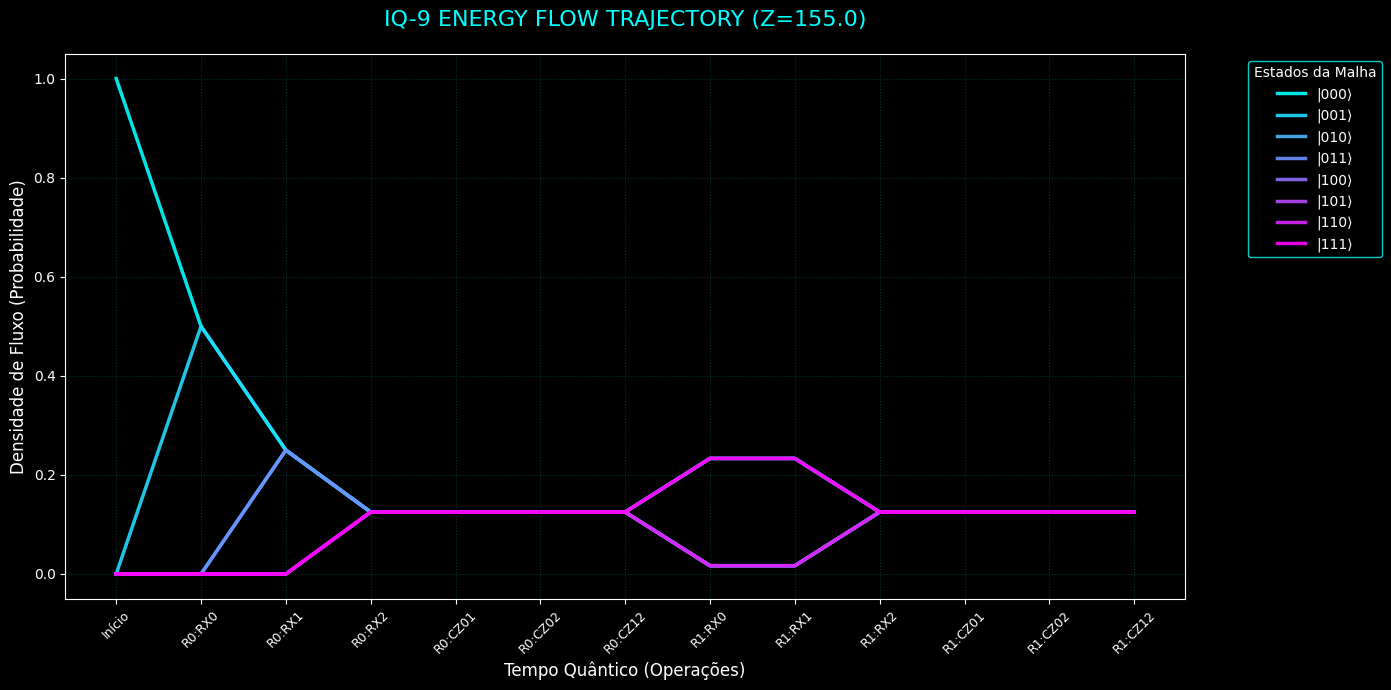


---------------------------------------------
📊 RELATÓRIO DE ESTABILIDADE DO PROCESSADOR
---------------------------------------------
🔹 Índice de Energia: 6.4583 Q-Units
✅ STATUS: FLUXO LAMINAR (DITRITIO ESTÁVEL)
---------------------------------------------


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import qiskit
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import RXGate, CZGate

def simulate_iq9_trajectories():
    print("="*70)
    print("🚀 SIMULAÇÃO DE TRAJETÓRIAS DE ENERGIA - IQ-9 (SUBSTRATO DITRITIO)")
    print("="*70)

    num_qubits = 3
    reps = 2  # Reduzido para maior clareza visual nas trajetórias
    z_factor = 155.0  # Fator Z de Tenacidade Quântica

    # 1. Preparação do Circuito e Rastreamento
    qc = QuantumCircuit(num_qubits)
    trajectories = []
    step_labels = ["Início"]

    # Captura estado inicial
    current_state = Statevector.from_instruction(qc)
    trajectories.append(np.abs(current_state.data)**2)

    # 2. Ciclo de Evolução na Malha
    for r in range(reps):
        # Rotação RX
        for i in range(num_qubits):
            qc.append(RXGate(np.pi/(r+2)), [i])
            current_state = Statevector.from_instruction(qc)
            trajectories.append(np.abs(current_state.data)**2)
            step_labels.append(f"R{r}:RX{i}")

        # Entalhamento CZ (Full-Mesh)
        connections = [(0,1), (0,2), (1,2)]
        for (i, j) in connections:
            qc.append(CZGate(), [i, j])
            current_state = Statevector.from_instruction(qc)
            trajectories.append(np.abs(current_state.data)**2)
            step_labels.append(f"R{r}:CZ{i}{j}")

    # 3. Processamento dos Dados
    traj_array = np.array(trajectories)
    num_steps = len(traj_array)
    energy_index = (np.mean(traj_array) * z_factor) / num_qubits

    # 4. Visualização Gráfica (Correção do Colormap)
    plt.figure(figsize=(14, 7))
    plt.style.use('dark_background')

    # Usando o Colormap 'cool' (Ciano/Magenta) para representar o Ditritio
    cmap = plt.get_cmap('cool')
    colors = cmap(np.linspace(0, 1, 2**num_qubits))

    for i in range(2**num_qubits):
        state_bin = format(i, f'0{num_qubits}b')
        plt.plot(range(num_steps), traj_array[:, i],
                 label=f'|{state_bin}⟩', alpha=0.9, linewidth=2.5, color=colors[i])

    plt.title(f"IQ-9 ENERGY FLOW TRAJECTORY (Z={z_factor})", fontsize=16, color='#00FFFF', pad=20)
    plt.xlabel("Tempo Quântico (Operações)", fontsize=12, color='white')
    plt.ylabel("Densidade de Fluxo (Probabilidade)", fontsize=12, color='white')

    # Ajuste de escala para os labels do eixo X
    plt.xticks(range(num_steps), step_labels, rotation=45, fontsize=9, color='white')
    plt.yticks(color='white')

    plt.grid(color='cyan', linestyle=':', alpha=0.2)
    plt.legend(title="Estados da Malha", bbox_to_anchor=(1.05, 1), loc='upper left', facecolor='black', edgecolor='cyan')
    plt.tight_layout()
    plt.show()

    # 5. Diagnóstico de Engenharia
    print("\n" + "-"*45)
    print(f"📊 RELATÓRIO DE ESTABILIDADE DO PROCESSADOR")
    print("-" * 45)
    print(f"🔹 Índice de Energia: {energy_index:.4f} Q-Units")

    if energy_index < 10.0:
        print("✅ STATUS: FLUXO LAMINAR (DITRITIO ESTÁVEL)")
    else:
        print("⚠️ STATUS: FLUXO TURBULENTO (REQUER Z-SHIELDING)")
    print("-" * 45)

# Executar a simulação corrigida
simulate_iq9_trajectories()